In [1]:
import argparse
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from functools import partial
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '../../Models'))
from models.GANs import SimpleGANGenerator
from models.noise import get_noise_function
from models.utils import EHRDataset
from utils.helpers import MongoExtractor
from models.utils import load_checkpoint

import yaml
import sys
import os
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
from functools import partial


from utils.helpers import MongoExtractor
from models.GANs import SimpleGANGenerator
from models.utils import EHRDataset
from train.train_cGAN_v1_1 import collate_fn, preprocess_data

from dotenv import load_dotenv

load_dotenv()


True

# Prognosis 

# ConditionalGAN

In [2]:
import torch
import numpy as np
import random
torch.cuda.empty_cache()



import argparse
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from functools import partial
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '../../Models'))
from models.GANs import SimpleGANGenerator
from models.noise import get_noise_function
from models.utils import EHRDataset
from utils.helpers import MongoExtractor
from models.utils import load_checkpoint

import yaml
import sys
import os
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
from functools import partial


from utils.helpers import MongoExtractor
from models.GANs import SimpleGANGenerator
from models.utils import EHRDataset
from train.train_cGAN_v1_1_markers import collate_fn, preprocess_data

from dotenv import load_dotenv

load_dotenv()


True

In [3]:
config_file = '../../Models/configs/config_v1_1_markers.yaml'
model_checkpoint = '/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-16_19-09-30_epochs_1000_bs_64_lrgen_0.001_lrdisc_0.0002_latent_10_optgen_adam_optdisc_adam_noise_uniform_criterion_MSELoss/checkpoints/generator_epoch_999.pth'
validation_data_config = '../../Models/configs/config_v1_1_val_markers.yaml'

In [4]:
def inference(generator, data_loader, noise_function, device):
    generator.eval()
    

    results = []
    real_features_list = []
    labels_list = []
    with torch.no_grad():
    

        for features, labels in data_loader:
            real_features = features
    

            # Generate noise for inference
            # noise = noise_function(real_features.size(0), device)
       
            # Concatenate features and noise
            generator_input = torch.cat((real_features, noise_function), dim=1)

            # Generate fake labels using the generator
            fake_labels = generator(generator_input)

            # Collect results
            results.append(fake_labels.cpu().numpy())
            real_features_list.append(real_features.cpu().numpy())
            labels_list.append(labels-1)

    return np.argmax(np.vstack(results), axis=1), np.vstack(labels_list).flatten().astype(int), real_features_list, np.vstack(results)
config = MongoExtractor.load_config(config_file)

# Extract data configuration
dc = config['data_config']

# Load training data
mongo_extractor_train = MongoExtractor(
    connection_string=os.getenv('MONGO_URI'),
    database_name=os.getenv('MONGO_DB'),
    collection_name=os.getenv('MONGO_COLLECTION'),
    config_file=config_file
)
df = mongo_extractor_train.get_dataframe_markers()

# Load validation data
mongo_extractor_val = MongoExtractor(
    connection_string=os.getenv('MONGO_URI'),
    database_name=os.getenv('MONGO_DB'),
    collection_name=os.getenv('MONGO_COLLECTION'),
    config_file=validation_data_config
)
df_val= mongo_extractor_val.get_dataframe_markers()
df_val_original = mongo_extractor_val.get_dataframe_markers()

dc = config['data_config']
mc = config['model_config']
sgc = config['simplegan_config']
mc['latent_dim'] = 10
mc['noise_type'] = 'uniform'
mc['batch_size'] = 1

df, df_val, scaler, label_encoder = preprocess_data(df, df_val, dc)

dataset_train = EHRDataset(df)
dataset_val = EHRDataset(df_val)

collate_fn_dc = partial(collate_fn, dc=dc)
data_loader_val = DataLoader(dataset_val, batch_size=mc['batch_size'], drop_last=True, collate_fn=collate_fn_dc)


exclude = list(set(dc['exclude_fields']) - set(dc['labels']))
df = df.drop(columns=exclude)
df = df.drop(columns=dc['labels'])
sgc['input_dim'] = df.shape[1] 

# Load the generator model and optimizer

generator = SimpleGANGenerator(input_dim=sgc['input_dim'] + mc['latent_dim'], output_dim=sgc['output_dim'])

device = torch.device('cpu')
optimizer_gen = torch.optim.Adam(generator.parameters(), lr=0.0001)  # Use the same optimizer as during training
generator, optimizer_gen, _, _ = load_checkpoint(model_checkpoint, generator, optimizer_gen)
torch.manual_seed(43)
noise_function = get_noise_function(mc)


Checkpoint loaded from /home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-16_19-09-30_epochs_1000_bs_64_lrgen_0.001_lrdisc_0.0002_latent_10_optgen_adam_optdisc_adam_noise_uniform_criterion_MSELoss/checkpoints/generator_epoch_999.pth


/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:195: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  binary_biomarkers_df[biomarker] = binary_biomarkers_df[biomarker] | column_values.apply(
/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:195: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  binary_biomarkers_df[biomarker] = binary_biomarkers_df[biomarker] | column_values.apply(
/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:195: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Serie

In [5]:
torch.manual_seed(43)
noise_function = get_noise_function(mc)
categorical_fields = list(set(dc['categorical_fields']) - set(dc['exclude_fields']))
all_features = df.columns.tolist()
numerical_fields = list(set(all_features) - set(categorical_fields) - set(dc['exclude_fields']))
pred_labels, real_labels, features, pred_prob = inference(generator, data_loader_val, noise_function, device)
pred_labels, real_labels, features, pred_prob

(array([1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
        0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
        1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0]),
 array([0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
        0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
        0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0]),
 [array([[0.08273381, 0.18345323, 0.19433199, 0.5529412 , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          1.        , 0.        , 0.        , 1.        , 1.        ,
          0.        , 0.        , 1.        ]], dtype=float32),


In [6]:
# Convert Tensors to DataFrame

# Convert tensors to a list of lists
features= np.array(features)
features_reshaped = features.reshape(-1, features.shape[-1])

column_names = ['age_admission', 'size_a', 'size_b', 'size_c',"MDM2", "EWSR1", "CD34", "BRAF", "ALK1" ,'group_B', 'group_D', 'group_S', 'intermediat', 'malign', 'metastasis_no', 'metastasis_si',  "male", "female" ]

# Create DataFrame
df_validation = pd.DataFrame(features_reshaped, columns=column_names)


# Display the DataFrame
df_validation[[ 'ALK1', 'BRAF', 'CD34', 'EWSR1', 'MDM2',  'size_a', 'size_b', 'size_c', 'age_admission' ]] = scaler.inverse_transform(df_validation[['ALK1', 'BRAF', 'CD34', 'EWSR1', 'MDM2',   'size_a', 'size_b', 'size_c', 'age_admission' ]])
df_validation['real_labels'] = real_labels
df_validation['predicted_labels'] = pred_labels

df_validation

,age_admission,size_a,size_b,size_c,MDM2,EWSR1,CD34,BRAF,ALK1,group_B,group_D,group_S,intermediat,malign,metastasis_no,metastasis_si,male,female,real_labels,predicted_labels
0,15.032373,207.000000,56.024296,139.576477,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0,1
1,NaN,NaN,NaN,209.317657,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1,0
2,NaN,NaN,NaN,220.941177,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0
3,NaN,NaN,NaN,64.023529,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0,1
4,11.592626,151.000000,42.518219,81.458832,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,10.369604,54.999996,15.506073,116.329414,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1,0
103,12.739209,215.000000,38.016197,72.741180,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1,1
104,13.044964,119.000000,26.761133,49.494118,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0
105,23.822842,499.000000,106.672066,81.458832,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0,1


Accuracy: 0.52


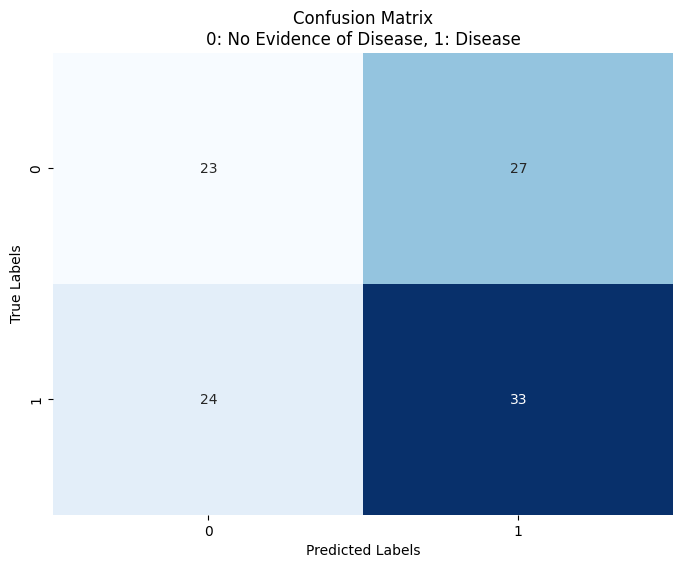

In [7]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt



# Compute confusion matrix
conf_matrix = confusion_matrix(df_validation['real_labels'], df_validation['predicted_labels'])
accuracy = accuracy_score(df_validation['real_labels'], df_validation['predicted_labels'])
print(f'Accuracy: {accuracy:.2f}')
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix\n0: No Evidence of Disease, 1: Disease')
plt.show()


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Define age intervals including 0-19
age_bins = [0, 20, 40, 60, 80, 100]
age_labels = ['0-19', '20-39', '40-59', '60-79', '80+']
df_validation['age_group'] = pd.cut(df_validation['age_admission'], bins=age_bins, labels=age_labels, right=False)

# Drop rows with NaN in real_labels or predicted_labels for calculation
df_clean = df_validation.dropna(subset=['real_labels', 'predicted_labels'])

# Model-based prediction accuracy by age group
df_clean['correct_model_prediction'] = df_clean['real_labels'] == df_clean['predicted_labels']
model_accuracy = df_clean.groupby('age_group')['correct_model_prediction'].mean() * 100

# Define threshold predictions based on the mode of real_labels in each age group
threshold_conditions = df_clean.groupby('age_group')['real_labels'].agg(lambda x: x.mode()[0])
df_clean['threshold_prediction'] = df_clean['age_group'].map(threshold_conditions)
df_clean['correct_threshold_prediction'] = df_clean['real_labels'] == df_clean['threshold_prediction']
threshold_accuracy = df_clean.groupby('age_group')['correct_threshold_prediction'].mean() * 100

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Bar width
bar_width = 0.35
index = np.arange(len(age_labels))

# Model accuracy bars
bar1 = ax.bar(index, model_accuracy, bar_width, label='Model Prediction Accuracy (%)', color='skyblue')

# Threshold accuracy bars
bar2 = ax.bar(index + bar_width, threshold_accuracy, bar_width, label='Threshold-Based Accuracy (%)', color='orange')

# Labels and titles
ax.set_xlabel('Age Group')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparison of Model Prediction Accuracy and Threshold-Based Accuracy Across Age Groups')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(age_labels)
ax.set_ylim(0, 100)

# Add legend
ax.legend()

plt.show()

/tmp/ipykernel_225454/2340108709.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_accuracy = df_clean.groupby('age_group')['correct_model_prediction'].mean() * 100
/tmp/ipykernel_225454/2340108709.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  threshold_conditions = df_clean.groupby('age_group')['real_labels'].agg(lambda x: x.mode()[0])


KeyError: 0

Brier Score - GAN (Median): 0.3818832270655563
Log Loss - GAN (Median): 2.0892946680216276
AUC-ROC - GAN (Median): 0.6750298685782556
Precision - GAN (Median): 0.5692307692307692
Recall - GAN (Median): 0.6851851851851852
F1 Score - GAN (Median): 0.6218487394957983
Accuracy - GAN (Median): 0.6120689655172413


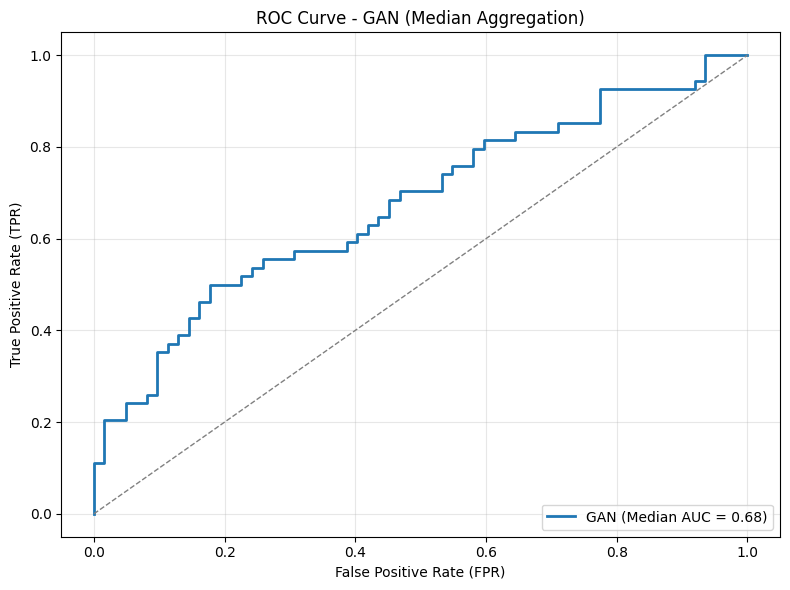

In [ ]:
import numpy as np
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    accuracy_score
)
import matplotlib.pyplot as plt
import torch

def aggregate_inference(generator, data_loader, num_samples, device):
    pred_probs = []
    for _ in range(num_samples):
        noise_function = get_noise_function(mc)
        # Generate predictions with new noise each time
        pred_labels, real_labels, features, pred_prob = inference(generator, data_loader, noise_function, device)
        pred_probs.append(pred_prob)
    return np.array(pred_probs), real_labels

# Simulated inputs (replace these with real outputs)
num_samples = 50 # Number of runs per data point with different noise
device = torch.device("cpu")  # Simulated GAN predictions

# Run aggregated inference
pred_probs_samples, real_labels = aggregate_inference(generator, data_loader_val, num_samples, device)

# Aggregate probabilities (median)
pred_probs_median = np.mean(pred_probs_samples, axis=0)
pred_probs_median = pred_probs_median / np.sum(pred_probs_median, axis=1, keepdims=True)

# Brier Score
brier_gan = brier_score_loss(real_labels, pred_probs_median[:, 1])

# Log Loss
log_loss_gan = log_loss(real_labels, pred_probs_median[:, 1])

# AUC-ROC Score
auc_roc_gan = roc_auc_score(real_labels, pred_probs_median[:, 1])

# Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
gan_predictions = np.argmax(np.vstack(pred_probs_median), axis=1)

# Precision, Recall, F1 Score
precision_gan = precision_score(real_labels, gan_predictions)
recall_gan = recall_score(real_labels, gan_predictions)
f1_gan = f1_score(real_labels, gan_predictions)

# Accuracy
accuracy_gan = accuracy_score(real_labels, gan_predictions)

# Print metrics
print("Brier Score - GAN (Median):", brier_gan)
print("Log Loss - GAN (Median):", log_loss_gan)
print("AUC-ROC - GAN (Median):", auc_roc_gan)
print("Precision - GAN (Median):", precision_gan)
print("Recall - GAN (Median):", recall_gan)
print("F1 Score - GAN (Median):", f1_gan)
print("Accuracy - GAN (Median):", accuracy_gan)

# Plot ROC Curve
fpr_gan, tpr_gan, _ = roc_curve(real_labels, pred_probs_median[:, 1])
roc_auc_gan = auc(fpr_gan, tpr_gan)

plt.figure(figsize=(8, 6))
plt.plot(fpr_gan, tpr_gan, label=f'GAN (Median AUC = {roc_auc_gan:.2f})', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.title('ROC Curve - GAN (Median Aggregation)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
pred_probs_median_cgan = pred_probs_median.copy()


In [ ]:
pred_probs_median 

array([[0.002255  , 0.99774504],
       [0.99565804, 0.00434194],
       [0.9974155 , 0.0025845 ],
       [0.00393427, 0.99606574],
       [0.9910099 , 0.00899013],
       [0.0040348 , 0.99596524],
       [0.00525516, 0.99474484],
       [0.99744666, 0.00255338],
       [0.00713788, 0.9928621 ],
       [0.00220934, 0.9977907 ],
       [0.9974055 , 0.00259448],
       [0.9973908 , 0.00260922],
       [0.00534881, 0.9946512 ],
       [0.00427417, 0.9957258 ],
       [0.00221791, 0.9977821 ],
       [0.00398519, 0.99601483],
       [0.00560302, 0.994397  ],
       [0.00222359, 0.99777645],
       [0.0028452 , 0.99715483],
       [0.9973909 , 0.00260906],
       [0.9974392 , 0.00256081],
       [0.9973852 , 0.00261483],
       [0.99739075, 0.00260925],
       [0.00535403, 0.99464595],
       [0.00525595, 0.99474406],
       [0.00226677, 0.9977332 ],
       [0.9975243 , 0.00247568],
       [0.0032875 , 0.99671245],
       [0.00525537, 0.99474466],
       [0.00272109, 0.99727887],
       [0.

# Wasserstaing GAN

In [ ]:
import torch
import numpy as np
import random
torch.cuda.empty_cache()



import argparse
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from functools import partial
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '../../Models'))
from models.GANs import SimpleGANGenerator
from models.noise import get_noise_function
from models.utils import EHRDataset
from utils.helpers import MongoExtractor
from models.utils import load_checkpoint

import yaml
import sys
import os
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
from functools import partial


from utils.helpers import MongoExtractor
from models.GANs import SimpleGANGenerator
from models.utils import EHRDataset
from train.train_wGAN_v1_1_markers import collate_fn, preprocess_data

from dotenv import load_dotenv

load_dotenv()


True

In [ ]:
config_file = '../../Models/configs/config_v1_1_markers.yaml'
model_checkpoint ='/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_09-26-05_epochs_1000_bs_64_lrgen_0.002_lrdisc_0.0002_latent_12_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss/checkpoints/generator_final.pth'
# '/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_09-07-50_epochs_1000_bs_64_lrgen_0.002_lrdisc_0.0002_latent_10_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss/checkpoints/generator_final.pth'
# '/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_09-26-05_epochs_1000_bs_64_lrgen_0.002_lrdisc_0.0002_latent_12_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss/checkpoints/generator_final.pth'
# '/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_01-01-16_epochs_1000_bs_64_lrgen_0.001_lrdisc_0.0002_latent_12_optgen_adam_optdisc_adam_noise_gaussian_criterion_MSELoss/checkpoints/generator_final.pth'
# '/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_00-43-15_epochs_1000_bs_64_lrgen_0.001_lrdisc_0.0002_latent_10_optgen_adam_optdisc_adam_noise_gaussian_criterion_MSELoss/checkpoints/generator_final.pth'
#/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_00-07-31_epochs_1000_bs_64_lrgen_0.0005_lrdisc_0.0002_latent_10_optgen_adam_optdisc_adam_noise_gaussian_criterion_MSELoss/checkpoints/generator_final.pth
validation_data_config = '../../Models/configs/config_v1_1_val_markers.yaml'

In [ ]:
def inference(generator, data_loader, noise_function, device):
    generator.eval()
    

    results = []
    real_features_list = []
    labels_list = []
    with torch.no_grad():
    

        for features, labels in data_loader:
            real_features = features
    

            # Generate noise for inference
            # noise = noise_function(real_features.size(0), device)
       
            # Concatenate features and noise
            generator_input = torch.cat((real_features, noise_function), dim=1)

            # Generate fake labels using the generator
            fake_labels = generator(generator_input)

            # Collect results
            results.append(fake_labels.cpu().numpy())
            real_features_list.append(real_features.cpu().numpy())
            labels_list.append(labels-1)

    return np.argmax(np.vstack(results), axis=1), np.vstack(labels_list).flatten().astype(int), real_features_list, np.vstack(results)
config = MongoExtractor.load_config(config_file)

# Extract data configuration
dc = config['data_config']

# Load training data
mongo_extractor_train = MongoExtractor(
    connection_string=os.getenv('MONGO_URI'),
    database_name=os.getenv('MONGO_DB'),
    collection_name=os.getenv('MONGO_COLLECTION'),
    config_file=config_file
)
df = mongo_extractor_train.get_dataframe_markers()

# Load validation data
mongo_extractor_val = MongoExtractor(
    connection_string=os.getenv('MONGO_URI'),
    database_name=os.getenv('MONGO_DB'),
    collection_name=os.getenv('MONGO_COLLECTION'),
    config_file=validation_data_config
)
df_val= mongo_extractor_val.get_dataframe_markers()
df_val_original = mongo_extractor_val.get_dataframe_markers()

dc = config['data_config']
mc = config['model_config']
sgc = config['simplegan_config']
mc['latent_dim'] = 12
mc['noise_type'] = 'uniform'
mc['batch_size'] = 1

df, df_val, scaler, label_encoder = preprocess_data(df, df_val, dc)

dataset_train = EHRDataset(df)
dataset_val = EHRDataset(df_val)

collate_fn_dc = partial(collate_fn, dc=dc)
data_loader_val = DataLoader(dataset_val, batch_size=mc['batch_size'], drop_last=True, collate_fn=collate_fn_dc)


exclude = list(set(dc['exclude_fields']) - set(dc['labels']))
df = df.drop(columns=exclude)
df = df.drop(columns=dc['labels'])
sgc['input_dim'] = df.shape[1] 

# Load the generator model and optimizer

generator = SimpleGANGenerator(input_dim=sgc['input_dim'] + mc['latent_dim'], output_dim=sgc['output_dim'])

device = torch.device('cpu')
optimizer_gen = torch.optim.Adam(generator.parameters(), lr=0.0001)  # Use the same optimizer as during training
generator, optimizer_gen, _, _ = load_checkpoint(model_checkpoint, generator, optimizer_gen)
torch.manual_seed(43)
noise_function = get_noise_function(mc)



/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:120: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  binary_biomarkers_df[biomarker] = binary_biomarkers_df[biomarker] | column_values.apply(
/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:120: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  binary_biomarkers_df[biomarker] = binary_biomarkers_df[biomarker] | column_values.apply(
/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:120: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Serie

Checkpoint loaded from /home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_09-26-05_epochs_1000_bs_64_lrgen_0.002_lrdisc_0.0002_latent_12_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss/checkpoints/generator_final.pth


In [ ]:
categorical_fields = list(set(dc['categorical_fields']) - set(dc['exclude_fields']))
all_features = df.columns.tolist()
numerical_fields = list(set(all_features) - set(categorical_fields) - set(dc['exclude_fields']))
pred_labels, real_labels, features, pred_prob = inference(generator, data_loader_val, noise_function, device)

In [ ]:
# Convert tensors to a list of lists
features= np.array(features)
features_reshaped = features.reshape(-1, features.shape[-1])

column_names = ['age_admission', 'size_a', 'size_b', 'size_c',"MDM2", "EWSR1", "CD34", "BRAF", "ALK1" ,'group_B', 'group_D', 'group_S', 'intermediat', 'malign', 'metastasis_no', 'metastasis_si',  "male", "female" ]

# Create DataFrame
df_validation = pd.DataFrame(features_reshaped, columns=column_names)


# Display the DataFrame
df_validation[[ 'ALK1', 'BRAF', 'CD34', 'EWSR1', 'MDM2',  'size_a', 'size_b', 'size_c', 'age_admission' ]] = scaler.inverse_transform(df_validation[['ALK1', 'BRAF', 'CD34', 'EWSR1', 'MDM2',   'size_a', 'size_b', 'size_c', 'age_admission' ]])
df_validation['real_labels'] = real_labels
df_validation['predicted_labels'] = pred_labels


df_validation[['no_disease', 'yes_disease']] = pred_prob
df_validation_w = df_validation.copy()


Accuracy: 0.62


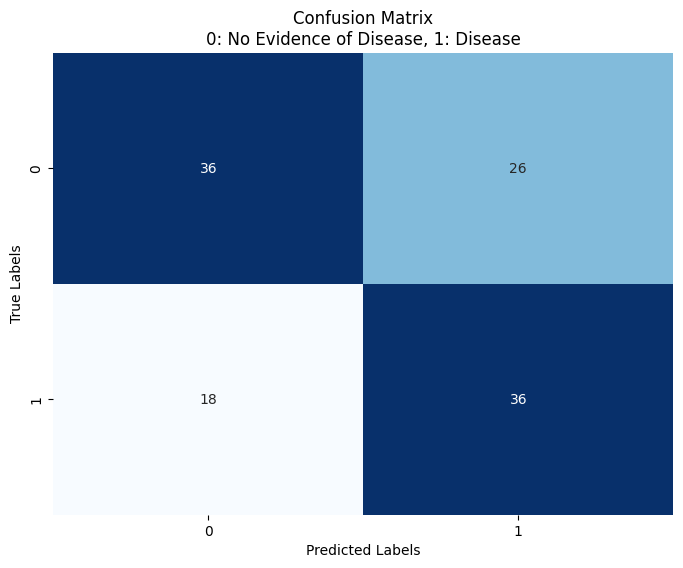

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt



# Compute confusion matrix
conf_matrix = confusion_matrix(df_validation['real_labels'], df_validation['predicted_labels'])
accuracy = accuracy_score(df_validation['real_labels'], df_validation['predicted_labels'])
print(f'Accuracy: {accuracy:.2f}')
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix\n0: No Evidence of Disease, 1: Disease')
plt.show()

/tmp/ipykernel_6363/1884798091.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_accuracy = df_clean.groupby('age_group')['correct_model_prediction'].mean() * 100
/tmp/ipykernel_6363/1884798091.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  threshold_conditions = df_clean.groupby('age_group')['real_labels'].agg(lambda x: x.mode()[0])
/tmp/ipykernel_6363/1884798091.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this 

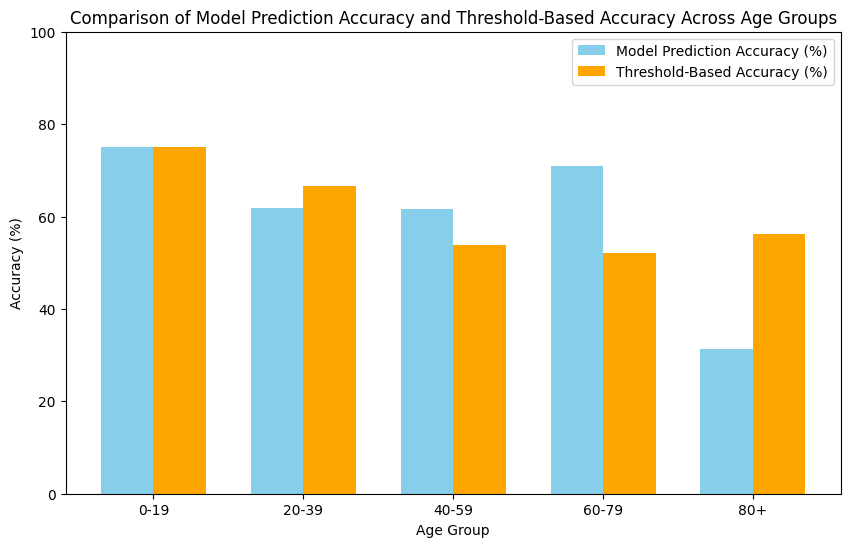

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Define age intervals including 0-19
age_bins = [0, 20, 40, 60, 80, 100]
age_labels = ['0-19', '20-39', '40-59', '60-79', '80+']
df_validation['age_group'] = pd.cut(df_validation['age_admission'], bins=age_bins, labels=age_labels, right=False)

# Drop rows with NaN in real_labels or predicted_labels for calculation
df_clean = df_validation.dropna(subset=['real_labels', 'predicted_labels'])

# Model-based prediction accuracy by age group
df_clean['correct_model_prediction'] = df_clean['real_labels'] == df_clean['predicted_labels']
model_accuracy = df_clean.groupby('age_group')['correct_model_prediction'].mean() * 100

# Define threshold predictions based on the mode of real_labels in each age group
threshold_conditions = df_clean.groupby('age_group')['real_labels'].agg(lambda x: x.mode()[0])
df_clean['threshold_prediction'] = df_clean['age_group'].map(threshold_conditions)
df_clean['correct_threshold_prediction'] = df_clean['real_labels'] == df_clean['threshold_prediction']
threshold_accuracy = df_clean.groupby('age_group')['correct_threshold_prediction'].mean() * 100

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Bar width
bar_width = 0.35
index = np.arange(len(age_labels))

# Model accuracy bars
bar1 = ax.bar(index, model_accuracy, bar_width, label='Model Prediction Accuracy (%)', color='skyblue')

# Threshold accuracy bars
bar2 = ax.bar(index + bar_width, threshold_accuracy, bar_width, label='Threshold-Based Accuracy (%)', color='orange')

# Labels and titles
ax.set_xlabel('Age Group')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparison of Model Prediction Accuracy and Threshold-Based Accuracy Across Age Groups')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(age_labels)
ax.set_ylim(0, 100)

# Add legend
ax.legend()

Brier Score - GAN (Median): 0.36425397681570026
Log Loss - GAN (Median): 2.1931913888844528
AUC-ROC - GAN (Median): 0.7107228195937874
Precision - GAN (Median): 0.5901639344262295
Recall - GAN (Median): 0.6666666666666666
F1 Score - GAN (Median): 0.6260869565217392
Accuracy - GAN (Median): 0.6293103448275862


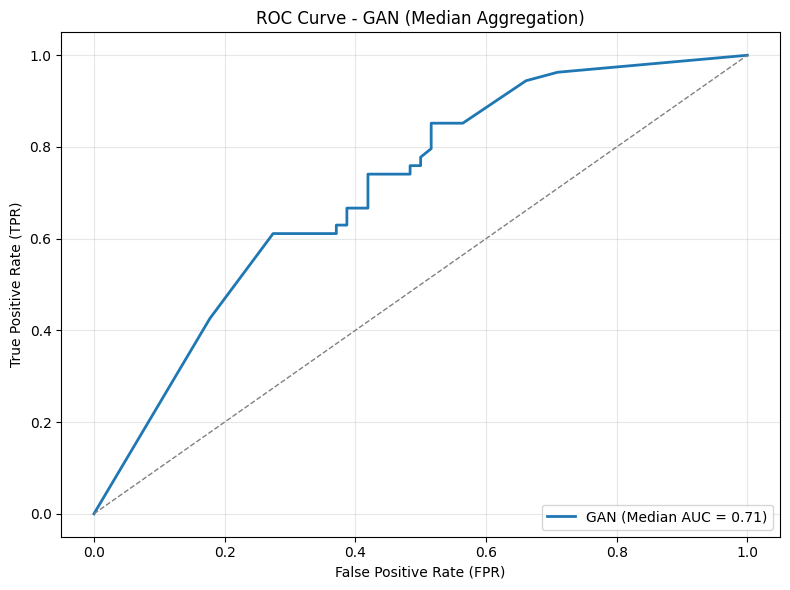

In [ ]:
import numpy as np
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    accuracy_score
)
import matplotlib.pyplot as plt
import torch

def aggregate_inference(generator, data_loader, num_samples, device):
    pred_probs = []
    for _ in range(num_samples):
        noise_function = get_noise_function(mc)
        # Generate predictions with new noise each time
        pred_labels, real_labels, features, pred_prob = inference(generator, data_loader, noise_function, device)
        pred_probs.append(pred_prob)
    return np.array(pred_probs), real_labels

# Simulated inputs (replace these with real outputs)
num_samples = 50 # Number of runs per data point with different noise
device = torch.device("cpu")  # Simulated GAN predictions

# Run aggregated inference
pred_probs_samples, real_labels = aggregate_inference(generator, data_loader_val, num_samples, device)

# Aggregate probabilities (median)
pred_probs_median = np.mean(pred_probs_samples, axis=0)
pred_probs_median = pred_probs_median / np.sum(pred_probs_median, axis=1, keepdims=True)

# Brier Score
brier_gan = brier_score_loss(real_labels, pred_probs_median[:, 1])

# Log Loss
log_loss_gan = log_loss(real_labels, pred_probs_median[:, 1])

# AUC-ROC Score
auc_roc_gan = roc_auc_score(real_labels, pred_probs_median[:, 1])

# Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
gan_predictions = np.argmax(np.vstack(pred_probs_median), axis=1)


# Precision, Recall, F1 Score
precision_gan = precision_score(real_labels, gan_predictions)
recall_gan = recall_score(real_labels, gan_predictions)
f1_gan = f1_score(real_labels, gan_predictions)

# Accuracy
accuracy_gan = accuracy_score(real_labels, gan_predictions)

# Print metrics
print("Brier Score - GAN (Median):", brier_gan)
print("Log Loss - GAN (Median):", log_loss_gan)
print("AUC-ROC - GAN (Median):", auc_roc_gan)
print("Precision - GAN (Median):", precision_gan)
print("Recall - GAN (Median):", recall_gan)
print("F1 Score - GAN (Median):", f1_gan)
print("Accuracy - GAN (Median):", accuracy_gan)

# Plot ROC Curve
fpr_gan, tpr_gan, _ = roc_curve(real_labels, pred_probs_median[:, 1])
roc_auc_gan = auc(fpr_gan, tpr_gan)

plt.figure(figsize=(8, 6))
plt.plot(fpr_gan, tpr_gan, label=f'GAN (Median AUC = {roc_auc_gan:.2f})', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.title('ROC Curve - GAN (Median Aggregation)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pred_probs_median_wgan = pred_probs_median.copy()


Witout markers

In [ ]:
def inference(generator, data_loader, noise_function, device):
    generator.eval()
    

    results = []
    real_features_list = []
    labels_list = []
    with torch.no_grad():
    

        for features, labels in data_loader:
            real_features = features
    

            # Generate noise for inference
            # noise = noise_function(real_features.size(0), device)
       
            # Concatenate features and noise
            generator_input = torch.cat((real_features, noise_function), dim=1)

            # Generate fake labels using the generator
            fake_labels = generator(generator_input)

            # Collect results
            results.append(fake_labels.cpu().numpy())
            real_features_list.append(real_features.cpu().numpy())
            labels_list.append(labels-1)

    return np.argmax(np.vstack(results), axis=1), np.vstack(labels_list).flatten().astype(int), real_features_list, np.vstack(results)
config = MongoExtractor.load_config(config_file)

# Extract data configuration
dc = config['data_config']

# Load training data
mongo_extractor_train = MongoExtractor(
    connection_string=os.getenv('MONGO_URI'),
    database_name=os.getenv('MONGO_DB'),
    collection_name=os.getenv('MONGO_COLLECTION'),
    config_file=config_file
)
df = mongo_extractor_train.get_dataframe_markers()

# Load validation data
mongo_extractor_val = MongoExtractor(
    connection_string=os.getenv('MONGO_URI'),
    database_name=os.getenv('MONGO_DB'),
    collection_name=os.getenv('MONGO_COLLECTION'),
    config_file=validation_data_config
)
df_val= mongo_extractor_val.get_dataframe_markers()
df_val_original = mongo_extractor_val.get_dataframe_markers()

dc = config['data_config']
mc = config['model_config']
sgc = config['simplegan_config']
mc['latent_dim'] = 12
mc['noise_type'] = 'uniform'
mc['batch_size'] = 1

df, df_val, scaler, label_encoder = preprocess_data(df, df_val, dc)

# Set Specified Columns to Zero
# Set all values to zero for the columns ['ALK1', 'BRAF', 'CD34', 'EWSR1', 'MDM2'] in each DataFrame.

# Set all values to zero for the specified columns
df[['ALK1', 'BRAF', 'CD34', 'EWSR1', 'MDM2']] = 0
df_val[['ALK1', 'BRAF', 'CD34', 'EWSR1', 'MDM2']] = 0
df_val_original[['ALK1', 'BRAF', 'CD34', 'EWSR1', 'MDM2']] = 0

dataset_train = EHRDataset(df)
dataset_val = EHRDataset(df_val)

collate_fn_dc = partial(collate_fn, dc=dc)
data_loader_val = DataLoader(dataset_val, batch_size=mc['batch_size'], drop_last=True, collate_fn=collate_fn_dc)


exclude = list(set(dc['exclude_fields']) - set(dc['labels']))
df = df.drop(columns=exclude)
df = df.drop(columns=dc['labels'])
sgc['input_dim'] = df.shape[1] 

# Load the generator model and optimizer

generator = SimpleGANGenerator(input_dim=sgc['input_dim'] + mc['latent_dim'], output_dim=sgc['output_dim'])

device = torch.device('cpu')
optimizer_gen = torch.optim.Adam(generator.parameters(), lr=0.0001)  # Use the same optimizer as during training
generator, optimizer_gen, _, _ = load_checkpoint(model_checkpoint, generator, optimizer_gen)
torch.manual_seed(43)
noise_function = get_noise_function(mc)

/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:120: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  binary_biomarkers_df[biomarker] = binary_biomarkers_df[biomarker] | column_values.apply(
/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:120: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  binary_biomarkers_df[biomarker] = binary_biomarkers_df[biomarker] | column_values.apply(
/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:120: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Serie

Checkpoint loaded from /home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_09-26-05_epochs_1000_bs_64_lrgen_0.002_lrdisc_0.0002_latent_12_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss/checkpoints/generator_final.pth


/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:120: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  binary_biomarkers_df[biomarker] = binary_biomarkers_df[biomarker] | column_values.apply(
/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:120: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  binary_biomarkers_df[biomarker] = binary_biomarkers_df[biomarker] | column_values.apply(
/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:120: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Serie

In [ ]:
categorical_fields = list(set(dc['categorical_fields']) - set(dc['exclude_fields']))
all_features = df.columns.tolist()
numerical_fields = list(set(all_features) - set(categorical_fields) - set(dc['exclude_fields']))
pred_labels, real_labels, features, pred_prob = inference(generator, data_loader_val, noise_function, device)

In [ ]:
# Convert tensors to a list of lists
features= np.array(features)
features_reshaped = features.reshape(-1, features.shape[-1])

column_names = ['age_admission', 'size_a', 'size_b', 'size_c',"MDM2", "EWSR1", "CD34", "BRAF", "ALK1" ,'group_B', 'group_D', 'group_S', 'intermediat', 'malign', 'metastasis_no', 'metastasis_si',  "male", "female" ]

# Create DataFrame
df_validation = pd.DataFrame(features_reshaped, columns=column_names)


# Display the DataFrame
df_validation[[ 'ALK1', 'BRAF', 'CD34', 'EWSR1', 'MDM2',  'size_a', 'size_b', 'size_c', 'age_admission' ]] = scaler.inverse_transform(df_validation[['ALK1', 'BRAF', 'CD34', 'EWSR1', 'MDM2',   'size_a', 'size_b', 'size_c', 'age_admission' ]])
df_validation['real_labels'] = real_labels
df_validation['predicted_labels'] = pred_labels

# df_validation_w = df_validation.copy()

Brier Score - GAN (Median): 0.3638571499164225
Log Loss - GAN (Median): 2.1599463201527804
AUC-ROC - GAN (Median): 0.7119175627240143
Precision - GAN (Median): 0.5797101449275363
Recall - GAN (Median): 0.7407407407407407
F1 Score - GAN (Median): 0.6504065040650406
Accuracy - GAN (Median): 0.6293103448275862


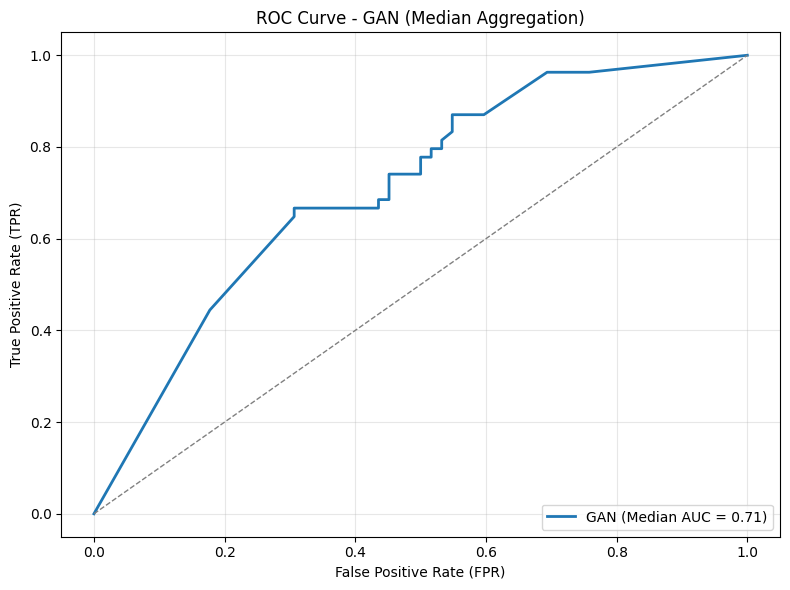

In [ ]:
import numpy as np
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    accuracy_score
)
import matplotlib.pyplot as plt
import torch

def aggregate_inference(generator, data_loader, num_samples, device):
    pred_probs = []
    for _ in range(num_samples):
        noise_function = get_noise_function(mc)
        # Generate predictions with new noise each time
        pred_labels, real_labels, features, pred_prob = inference(generator, data_loader, noise_function, device)
        pred_probs.append(pred_prob)
    return np.array(pred_probs), real_labels

# Simulated inputs (replace these with real outputs)
num_samples = 50 # Number of runs per data point with different noise
device = torch.device("cpu")  # Simulated GAN predictions

# Run aggregated inference
pred_probs_samples, real_labels = aggregate_inference(generator, data_loader_val, num_samples, device)

# Aggregate probabilities (median)
pred_probs_median = np.mean(pred_probs_samples, axis=0)
pred_probs_median = pred_probs_median / np.sum(pred_probs_median, axis=1, keepdims=True)

# Brier Score
brier_gan = brier_score_loss(real_labels, pred_probs_median[:, 1])

# Log Loss
log_loss_gan = log_loss(real_labels, pred_probs_median[:, 1])

# AUC-ROC Score
auc_roc_gan = roc_auc_score(real_labels, pred_probs_median[:, 1])

# Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
gan_predictions = np.argmax(np.vstack(pred_probs_median), axis=1)

# Precision, Recall, F1 Score
precision_gan = precision_score(real_labels, gan_predictions)
recall_gan = recall_score(real_labels, gan_predictions)
f1_gan = f1_score(real_labels, gan_predictions)

# Accuracy
accuracy_gan = accuracy_score(real_labels, gan_predictions)

# Print metrics
print("Brier Score - GAN (Median):", brier_gan)
print("Log Loss - GAN (Median):", log_loss_gan)
print("AUC-ROC - GAN (Median):", auc_roc_gan)
print("Precision - GAN (Median):", precision_gan)
print("Recall - GAN (Median):", recall_gan)
print("F1 Score - GAN (Median):", f1_gan)
print("Accuracy - GAN (Median):", accuracy_gan)

# Plot ROC Curve
fpr_gan, tpr_gan, _ = roc_curve(real_labels, pred_probs_median[:, 1])
roc_auc_gan = auc(fpr_gan, tpr_gan)

plt.figure(figsize=(8, 6))
plt.plot(fpr_gan, tpr_gan, label=f'GAN (Median AUC = {roc_auc_gan:.2f})', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.title('ROC Curve - GAN (Median Aggregation)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# DNN

In [ ]:
import torch
import numpy as np
import random
torch.cuda.empty_cache()



import argparse
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from functools import partial
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '../../Models'))
from models.GANs import SimpleGANGenerator
from models.noise import get_noise_function
from models.utils import EHRDataset
from utils.helpers import MongoExtractor
from models.utils import load_checkpoint

import yaml
import sys
import os
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
from functools import partial


from utils.helpers import MongoExtractor
from models.GANs import SimpleGANGenerator
from models.utils import EHRDataset
from train.train_DNN_v1_1_markers import collate_fn, preprocess_data

from dotenv import load_dotenv

load_dotenv()


True

In [ ]:
config_file = '../../Models/configs/config_v1_1_markers.yaml'
model_checkpoint = '/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_10-24-32_epochs_500_bs_64_lrgen_0.0001_lrdisc__latent_0_optgen_adam_optdisc__noise_uniform_criterion_MSELoss/checkpoints/generator_epoch_499.pth'
# '/home/andrea/Desktop/StoreModels/markers_new_selection/DNN/checkpoints/generator.pth'
validation_data_config = '../../Models/configs/config_v1_1_val_markers.yaml'

In [ ]:
def inference(generator, data_loader, device):
    generator.eval()

    results = []
    real_features_list = []
    labels_list = []
    with torch.no_grad():

        for features, labels in data_loader:
            real_features = features

            # Generate noise for inference
            # noise = noise_function(real_features.size(0), device)
       
            # Concatenate features and noise
            generator_input = real_features

            # Generate fake labels using the generator
            fake_labels = generator(generator_input)

            # Collect results
            results.append(fake_labels.cpu().numpy())
            real_features_list.append(real_features.cpu().numpy())
            labels_list.append(labels-1)

    return np.argmax(np.vstack(results), axis=1), np.vstack(labels_list).flatten().astype(int), real_features_list, np.vstack(results)
config = MongoExtractor.load_config(config_file)

# Extract data configuration
dc = config['data_config']

# Load training data
mongo_extractor_train = MongoExtractor(
    connection_string=os.getenv('MONGO_URI'),
    database_name=os.getenv('MONGO_DB'),
    collection_name=os.getenv('MONGO_COLLECTION'),
    config_file=config_file
)
df = mongo_extractor_train.get_dataframe_markers()

# Load validation data/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_09-26-05_epochs_1000_bs_64_lrgen_0.002_lrdisc_0.0002_latent_12_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss/checkpoints/generator_final.pth
mongo_extractor_val = MongoExtractor(
    connection_string=os.getenv('MONGO_URI'),
    database_name=os.getenv('MONGO_DB'),
    collection_name=os.getenv('MONGO_COLLECTION'),
    config_file=validation_data_config
)
df_val= mongo_extractor_val.get_dataframe_markers()
df_val_original = mongo_extractor_val.get_dataframe_markers()

dc = config['data_config']
mc = config['model_config']
sgc = config['simplegan_config']
mc['latent_dim'] = 0
mc['noise_type'] = 'uniform'
mc['batch_size'] = 1

df, df_val, scaler, label_encoder = preprocess_data(df, df_val, dc)

dataset_train = EHRDataset(df)
dataset_val = EHRDataset(df_val)

collate_fn_dc = partial(collate_fn, dc=dc)
data_loader_val = DataLoader(dataset_val, batch_size=mc['batch_size'], drop_last=True, collate_fn=collate_fn_dc)


exclude = list(set(dc['exclude_fields']) - set(dc['labels']))
df = df.drop(columns=exclude)
df = df.drop(columns=dc['labels'])
sgc['input_dim'] = df.shape[1] 

# Load the generator model and optimizer

generator = SimpleGANGenerator(input_dim=sgc['input_dim'] + mc['latent_dim'], output_dim=sgc['output_dim'])

device = torch.device('cpu')
optimizer_gen = torch.optim.Adam(generator.parameters(), lr=0.0001)  # Use the same optimizer as during training
generator, optimizer_gen, _, _ = load_checkpoint(model_checkpoint, generator, optimizer_gen)



/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:120: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  binary_biomarkers_df[biomarker] = binary_biomarkers_df[biomarker] | column_values.apply(
/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:120: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  binary_biomarkers_df[biomarker] = binary_biomarkers_df[biomarker] | column_values.apply(
/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:120: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Serie

Checkpoint loaded from /home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_10-24-32_epochs_500_bs_64_lrgen_0.0001_lrdisc__latent_0_optgen_adam_optdisc__noise_uniform_criterion_MSELoss/checkpoints/generator_epoch_499.pth


/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:120: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  binary_biomarkers_df[biomarker] = binary_biomarkers_df[biomarker] | column_values.apply(
/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:120: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  binary_biomarkers_df[biomarker] = binary_biomarkers_df[biomarker] | column_values.apply(
/home/andrea/Desktop/Sarcoma-DT/Models/visualizzations/../../Models/utils/helpers.py:120: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Serie

In [ ]:
categorical_fields = list(set(dc['categorical_fields']) - set(dc['exclude_fields']))
all_features = df.columns.tolist()
numerical_fields = list(set(all_features) - set(categorical_fields) - set(dc['exclude_fields']))
pred_labels, real_labels, features, pred_prob = inference(generator, data_loader_val, device)


In [ ]:
pred_prob


array([[0.2758045 , 0.7327364 ],
       [0.2949234 , 0.6579953 ],
       [0.9859505 , 0.01895753],
       [0.47336495, 0.50077766],
       [0.01523735, 0.9704207 ],
       [0.23893619, 0.7950024 ],
       [0.7469191 , 0.29188296],
       [0.9740587 , 0.03625467],
       [0.9566338 , 0.04951022],
       [0.34268007, 0.6305506 ],
       [0.95332146, 0.06620536],
       [0.5711225 , 0.466288  ],
       [0.5085825 , 0.58283865],
       [0.3000305 , 0.712795  ],
       [0.38104028, 0.609157  ],
       [0.37516835, 0.65094686],
       [0.9256511 , 0.06943782],
       [0.10274179, 0.8916789 ],
       [0.27353337, 0.7377492 ],
       [0.1459067 , 0.86979586],
       [0.39500278, 0.580735  ],
       [0.26029757, 0.6892409 ],
       [0.4672104 , 0.52411205],
       [0.7549666 , 0.24194591],
       [0.7637192 , 0.27693576],
       [0.13671666, 0.88135767],
       [0.08314405, 0.93587   ],
       [0.58622   , 0.4343484 ],
       [0.04541293, 0.95719403],
       [0.36456296, 0.62666154],
       [0.

In [ ]:
# Convert tensors to a list of lists
features= np.array(features)
features_reshaped = features.reshape(-1, features.shape[-1])

column_names = ['age_admission', 'size_a', 'size_b', 'size_c',"MDM2", "EWSR1", "CD34", "BRAF", "ALK1" ,'group_B', 'group_D', 'group_S', 'intermediat', 'malign', 'metastasis_no', 'metastasis_si',  "male", "female" ]

# Create DataFrame
df_validation = pd.DataFrame(features_reshaped, columns=column_names)


# Display the DataFrame
df_validation[[ 'ALK1', 'BRAF', 'CD34', 'EWSR1', 'MDM2',  'size_a', 'size_b', 'size_c', 'age_admission' ]] = scaler.inverse_transform(df_validation[['ALK1', 'BRAF', 'CD34', 'EWSR1', 'MDM2',   'size_a', 'size_b', 'size_c', 'age_admission' ]])
df_validation['real_labels'] = real_labels
df_validation['predicted_labels'] = pred_labels
df_validation[['no_disease', 'yes_disease']] = pred_prob
df_validation

,age_admission,size_a,size_b,size_c,MDM2,EWSR1,CD34,BRAF,ALK1,group_B,...,intermediat,malign,metastasis_no,metastasis_si,male,female,real_labels,predicted_labels,no_disease,yes_disease
0,72.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,1,1,0.275804,0.732736
1,73.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1,1,0.294923,0.657995
2,50.0,72.000008,69.000000,36.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1,0,0.985951,0.018958
3,79.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1,1,0.473365,0.500778
4,35.0,49.999996,39.000000,39.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1,1,0.015237,0.970421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,35.0,88.000000,76.000000,34.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0,0,0.936649,0.081920
112,27.0,46.000000,37.000004,20.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1,1,0.264826,0.718053
113,81.0,199.999985,179.999985,150.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1,1,0.068027,0.903349
114,66.0,209.999985,10.999999,NaN,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0,1,0.131389,0.880549


In [ ]:
def calculate_largest_size(row):
    # Get the largest size in mm, then convert to cm
    max_size_mm = max(row['size_a'], row['size_b'], row['size_c'])
    max_size_cm = max_size_mm / 10  # Convert mm to cm
    return max_size_cm

# Function to determine tumor/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_09-26-05_epochs_1000_bs_64_lrgen_0.002_lrdisc_0.0002_latent_12_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss/checkpoints/generator_final.pth size stage based on largest size in cm
def determine_size_stage(max_size_cm):
    if max_size_cm <= 5:
        return "T1"  # ≤ 5 cm
    elif max_size_cm <= 10:
        return "T2"  # > 5 cm and ≤ 10 cm
    elif max_size_cm <= 15:
        return "T3"  # > 10 cm and ≤ 15 cm
    else:
        return "T4"  # > 15 cm

# Function to determine metastasis stage
def determine_metastasis_stage(row):
    return "M1" if row['metastasis_si'] > 0 else "M0"

# Function to determine grade based on malignancy indicators
def determine_grade(row):
    if row['malign'] > 0:
        return "G3"  # High grade
    elif row['intermediat'] > 0:
        return "G2"  # Intermediate grade
    else:
        return "G1"  # Low grade

def assign_stage(row):
    max_size_cm = calculate_largest_size(row)
    size_stage = determine_size_stage(max_size_cm)
    metastasis_stage = determine_metastasis_stage(row)
    grade = determine_grade(row)
    
    # Stage assignment and OS probability based on refined AJCC logic and provided probabilities
    if metastasis_stage == "M1":
        stage, prob = "Stage IV", 0.124  # 12.4% OS for Stage IV (M1)
    elif grade == "G1" and metastasis_stage == "M0":
        stage, prob = "Stage I", 0.90  # Estimated ~90% OS for Stage I
    elif grade in ["G2", "G3"] and size_stage in ["T1", "T2"] and metastasis_stage == "M0":
        stage, prob = "Stage II", 0.70  # Estimated ~70% OS for Stage II
    elif grade == "G3" and size_stage in ["T3", "T4"] and metastasis_stage == "M0":
        stage, prob = "Stage III", 0.501  # 50.1% OS for Stage IIIB
    else:
        stage, prob = "Stage IIIA", 0.624  # 62.4% OS for Stage IIIA
    
    # Calculate the difference between staging probability and actual outcome
    outcome_diff = abs(1- prob)
    
    return stage, prob, outcome_diff
df_validation = df_validation_w.copy()
# Calculate largest size in cm for each row, determine staging, probability, and difference
df_validation['max_size_cm'] = df_validation.apply(calculate_largest_size, axis=1)
df_validation[['staging', 'staging_prob', 'staging_off']] = df_validation.apply(assign_stage, axis=1, result_type="expand")

# Display the resulting DataFrame with staging, probabilities, and difference
print(df_validation[['yes_disease', 'yes_disease', 'staging_prob', 'staging_off', 'real_labels']])



     yes_disease  yes_disease  staging_prob  staging_off  real_labels
0       0.998228     0.998228         0.501        0.499            1
1       0.001913     0.001913         0.501        0.499            1
2       0.001913     0.001913         0.700        0.300            1
3       0.998228     0.998228         0.501        0.499            1
4       0.998228     0.998228         0.124        0.876            1
..           ...          ...           ...          ...          ...
111     0.998228     0.998228         0.700        0.300            0
112     0.001913     0.001913         0.700        0.300            1
113     0.001913     0.001913         0.501        0.499            1
114     0.001913     0.001913         0.501        0.499            0
115     0.998228     0.998228         0.700        0.300            1

[116 rows x 5 columns]


Log Loss - Model: 2.3476969306605455
Log Loss - Staging (adjusted for disease): 0.657207973755187
AUC-ROC - Model: 0.6384408602150538
AUC-ROC - Staging (adjusted for disease): 0.6844384707287933
Precision - Model: 0.5806451612903226
Precision - Staging (adjusted for disease): 0.6666666666666666
Recall - Model: 0.6666666666666666
Recall - Staging (adjusted for disease): 0.07407407407407407
F1 Score - Model: 0.6206896551724138
F1 Score - Staging (adjusted for disease): 0.13333333333333333


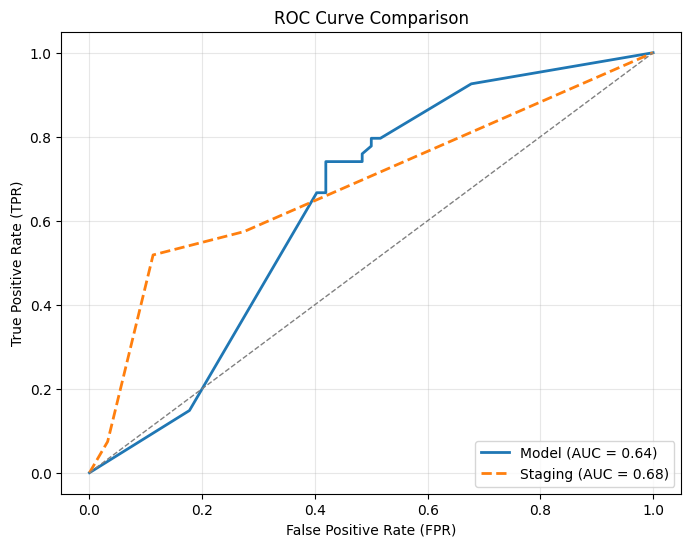

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

# Assuming df_validation is defined with columns: 'no_disease', 'yes_disease', 'staging_prob', 'staging_off', 'real_labels'

# Adjust `staging_prob` to represent the probability of disease presence, matching `yes_disease`
df_validation['staging_disease_prob'] = 1 - df_validation['staging_prob']

# Brier Score
brier_model = brier_score_loss(df_validation['real_labels'], df_validation['yes_disease'])
brier_staging = brier_score_loss(df_validation['real_labels'], df_validation['staging_disease_prob'])

# Log Loss
log_loss_model = log_loss(df_validation['real_labels'], df_validation['yes_disease'])
log_loss_staging = log_loss(df_validation['real_labels'], df_validation['staging_disease_prob'])

# AUC-ROC Score
auc_roc_model = roc_auc_score(df_validation['real_labels'], df_validation['yes_disease'])
auc_roc_staging = roc_auc_score(df_validation['real_labels'], df_validation['staging_disease_prob'])

# Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
model_predictions = (df_validation['yes_disease'] >= 0.5).astype(int)
staging_predictions = (df_validation['staging_disease_prob'] >= 0.5).astype(int)

# Precision, Recall, F1 Score
precision_model = precision_score(df_validation['real_labels'], model_predictions)
recall_model = recall_score(df_validation['real_labels'], model_predictions)
f1_model = f1_score(df_validation['real_labels'], model_predictions)

precision_staging = precision_score(df_validation['real_labels'], staging_predictions)
recall_staging = recall_score(df_validation['real_labels'], staging_predictions)
f1_staging = f1_score(df_validation['real_labels'], staging_predictions)

# Print all scores/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_00-07-31_epochs_1000_bs_64_lrgen_0.0005_lrdisc_0.0002_latent_10_optgen_adam_optdisc_adam_noise_gaussian_criterion_MSELoss/checkpoints/generator_final.pth
print("Log Loss - Model:", log_loss_model)
print("Log Loss - Staging (adjusted for disease):", log_loss_staging)

print("AUC-ROC - Model:", auc_roc_model)
print("AUC-ROC - Staging (adjusted for disease):", auc_roc_staging)

print("Precision - Model:", precision_model)
print("Precision - Staging (adjusted for disease):", precision_staging)

print("Recall - Model:", recall_model)
print("Recall - Staging (adjusted for disease):", recall_staging)

print("F1 Score - Model:", f1_model)
print("F1 Score - Staging (adjusted for disease):", f1_staging)

# ROC Curve Plot
# Calculate ROC curve and AUC for the model's probabilities
fpr_model, tpr_model, _ = roc_curve(df_validation['real_labels'], df_validation['yes_disease'])
roc_auc_model = auc(fpr_model, tpr_model)

# Calculate ROC curve and AUC for the staging probabilities
fpr_staging, tpr_staging, _ = roc_curve(df_validation['real_labels'], df_validation['staging_disease_prob'])
roc_auc_staging = auc(fpr_staging, tpr_staging)

# Plot the ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_model, tpr_model, label=f'Model (AUC = {roc_auc_model:.2f})', lw=2)
plt.plot(fpr_staging, tpr_staging, label=f'Staging (AUC = {roc_auc_staging:.2f})', lw=2, linestyle='--')

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

# Plot settings
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
# plt.tight_layout().astype(int)
config = MongoExtractor.load_config(config_file)

plt.show()




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

# Assuming df_validation is defined with columns: 'no_disease', 'yes_disease', 'staging_prob', 'staging_off', 'real_labels'

# Adjust `staging_prob` to represent the probability of disease presence, matching `yes_disease`
df_validation['staging_disease_prob'] = 1 - df_validation['staging_prob']

# Brier Score
brier_model = brier_score_loss(df_validation['real_labels'], df_validation['yes_disease'])
brier_staging = brier_score_loss(df_validation['real_labels'], df_validation['staging_disease_prob'])

# Log Loss
log_loss_model = log_loss(df_validation['real_labels'], df_validation['yes_disease'])
log_loss_staging = log_loss(df_validation['real_labels'], df_validation['staging_disease_prob'])

# AUC-ROC Score
auc_roc_model = roc_auc_score(df_validation['real_labels'], df_validation['yes_disease'])
auc_roc_staging = roc_auc_score(df_validation['real_labels'], df_validation['staging_disease_prob'])

# Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
model_predictions = (df_validation['yes_disease'] >= 0.5).astype(int)
staging_predictions = (df_validation['staging_disease_prob'] >= 0.5).astype(int)

# Precision, Recall, F1 Score
precision_model = precision_score(df_validation['real_labels'], model_predictions)
recall_model = recall_score(df_validation['real_labels'], model_predictions)
f1_model = f1_score(df_validation['real_labels'], model_predictions)

precision_staging = precision_score(df_validation['real_labels'], staging_predictions)
recall_staging = recall_score(df_validation['real_labels'], staging_predictions)
f1_staging = f1_score(df_validation['real_labels'], staging_predictions)

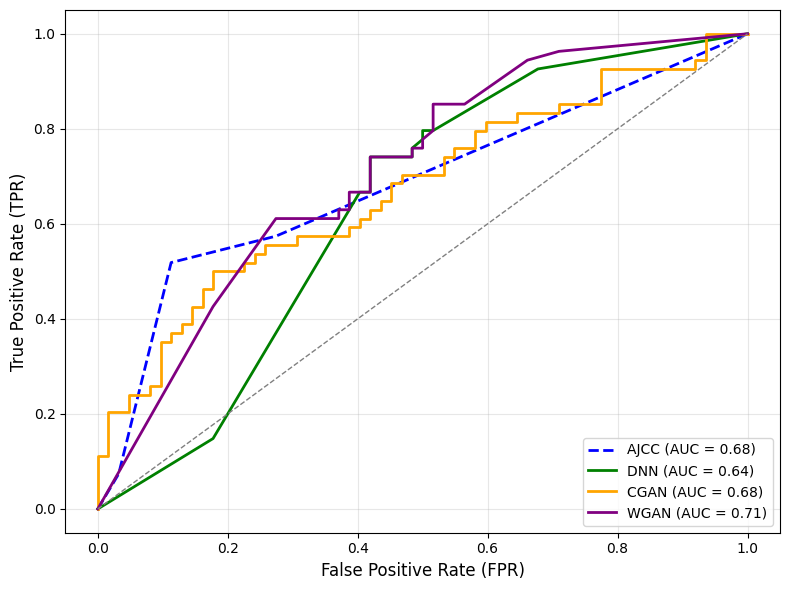

In [ ]:
fpr_cgan, tpr_cgan, _ = roc_curve(df_validation['real_labels'], pred_probs_median_cgan[:, 1])
roc_auc_cgan = auc(fpr_cgan, tpr_cgan)

fpr_wgan, tpr_wgan, _ = roc_curve(df_validation['real_labels'], pred_probs_median_wgan[:, 1])
roc_auc_wgan = auc(fpr_wgan, tpr_wgan)

fpr_model, tpr_model, _ = roc_curve(df_validation['real_labels'], df_validation['yes_disease'])
roc_auc_model = auc(fpr_model, tpr_model)

fpr_staging, tpr_staging, _ = roc_curve(df_validation['real_labels'], df_validation['staging_disease_prob'])
roc_auc_staging = auc(fpr_staging, tpr_staging)

# Plot the ROC curves with improved visual quality and subdued colors
plt.figure(figsize=(8, 6))

# Adjusted colors for less brightness
plt.plot(fpr_staging, tpr_staging, label=f'AJCC (AUC = {roc_auc_staging:.2f})', lw=2, linestyle='--', color='blue')
plt.plot(fpr_model, tpr_model, label=f'DNN (AUC = {roc_auc_model:.2f})', lw=2, color='green')
plt.plot(fpr_cgan, tpr_cgan, label=f'CGAN (AUC = {roc_auc_cgan:.2f})', lw=2, color='orange')
plt.plot(fpr_wgan, tpr_wgan, label=f'WGAN (AUC = {roc_auc_wgan:.2f})', lw=2, color='purple')

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

# Plot settings
# plt.title('ROC Curve Comparison', fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


Accuracy: 0.62


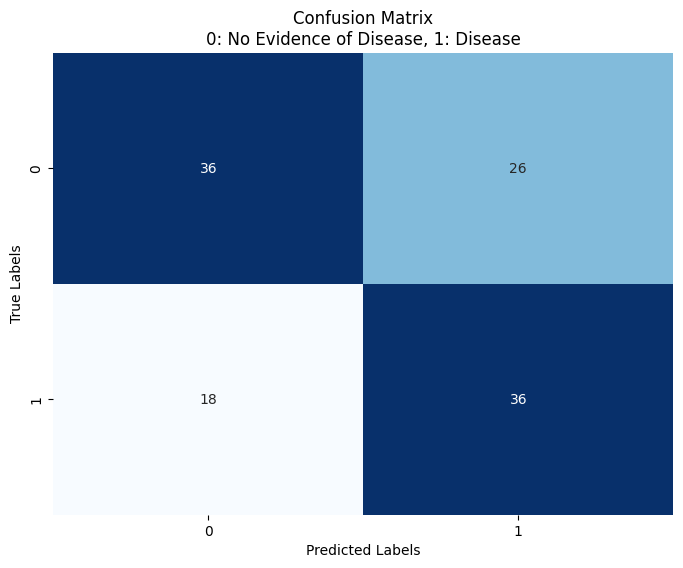

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt



# Compute confusion matrix
conf_matrix = confusion_matrix(df_validation['real_labels'], df_validation['predicted_labels'])
accuracy = accuracy_score(df_validation['real_labels'], df_validation['predicted_labels'])
print(f'Accuracy: {accuracy:.2f}')
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix\n0: No Evidence of Disease, 1: Disease')
plt.show()

/tmp/ipykernel_6363/2340108709.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_accuracy = df_clean.groupby('age_group')['correct_model_prediction'].mean() * 100
/tmp/ipykernel_6363/2340108709.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  threshold_conditions = df_clean.groupby('age_group')['real_labels'].agg(lambda x: x.mode()[0])
/tmp/ipykernel_6363/2340108709.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this 

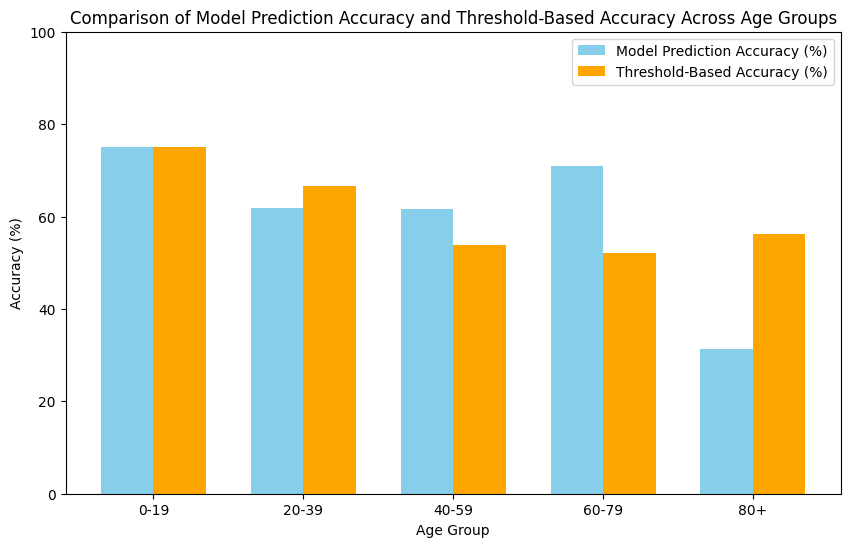

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Define age intervals including 0-19
age_bins = [0, 20, 40, 60, 80, 100]
age_labels = ['0-19', '20-39', '40-59', '60-79', '80+']
df_validation['age_group'] = pd.cut(df_validation['age_admission'], bins=age_bins, labels=age_labels, right=False)

# Drop rows with NaN in real_labels or predicted_labels for calculation
df_clean = df_validation.dropna(subset=['real_labels', 'predicted_labels'])

# Model-based prediction accuracy by age group
df_clean['correct_model_prediction'] = df_clean['real_labels'] == df_clean['predicted_labels']
model_accuracy = df_clean.groupby('age_group')['correct_model_prediction'].mean() * 100

# Define threshold predictions based on the mode of real_labels in each age group
threshold_conditions = df_clean.groupby('age_group')['real_labels'].agg(lambda x: x.mode()[0])
df_clean['threshold_prediction'] = df_clean['age_group'].map(threshold_conditions)
df_clean['correct_threshold_prediction'] = df_clean['real_labels'] == df_clean['threshold_prediction']
threshold_accuracy = df_clean.groupby('age_group')['correct_threshold_prediction'].mean() * 100

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Bar width
bar_width = 0.35
index = np.arange(len(age_labels))

# Model accuracy bars
bar1 = ax.bar(index, model_accuracy, bar_width, label='Model Prediction Accuracy (%)', color='skyblue')

# Threshold accuracy bars
bar2 = ax.bar(index + bar_width, threshold_accuracy, bar_width, label='Threshold-Based Accuracy (%)', color='orange')

# Labels and titles
ax.set_xlabel('Age Group')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparison of Model Prediction Accuracy and Threshold-Based Accuracy Across Age Groups')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(age_labels)
ax.set_ylim(0, 100)

# Add legend
ax.legend()

plt.show()

In [ ]:

# Assuming df is your DataFrame
# Step 1: Filter low-risk cases according to staging
low_risk_staging = df_validation[df_validation['staging_disease_prob'] < 0.5]

# Step 2: Identify actual high-risk cases
actual_high_risk = low_risk_staging[low_risk_staging['real_labels'] == 1]

# Step 3: Find cases where the model predicts correctly
model_correct = actual_high_risk[actual_high_risk['predicted_labels'] == 1]

# Step 4: Display or export the relevant cases
model_correct

,age_admission,size_a,size_b,size_c,MDM2,EWSR1,CD34,BRAF,ALK1,group_B,...,real_labels,predicted_labels,no_disease,yes_disease,max_size_cm,staging,staging_prob,staging_off,staging_disease_prob,age_group
0,72.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0.001604,0.998228,NaN,Stage III,0.501,0.499,0.499,60-79
3,79.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0.001604,0.998228,NaN,Stage III,0.501,0.499,0.499,60-79
5,71.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0.001604,0.998228,NaN,Stage III,0.501,0.499,0.499,60-79
9,52.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0.001604,0.998228,NaN,Stage III,0.501,0.499,0.499,40-59
13,50.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0.001604,0.998228,NaN,Stage III,0.501,0.499,0.499,40-59
14,56.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0.001604,0.998228,NaN,Stage III,0.501,0.499,0.499,40-59
15,75.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0.001604,0.998228,NaN,Stage III,0.501,0.499,0.499,60-79
16,31.999998,39.999996,38.000000,36.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0.001604,0.998228,4.000000,Stage II,0.700,0.300,0.300,20-39
17,71.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,...,1,1,0.001604,0.998228,NaN,Stage III,0.501,0.499,0.499,60-79
18,76.000000,44.999996,35.000000,20.000000,0.0,0.0,0.0,0.0,0.0,1.0,...,1,1,0.001604,0.998228,4.500000,Stage II,0.700,0.300,0.300,60-79


/tmp/ipykernel_6363/2560337212.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_correct['max_size_cm_filled'] = model_correct['max_size_cm'].fillna(-1)  # Use -1 to indicate missing size


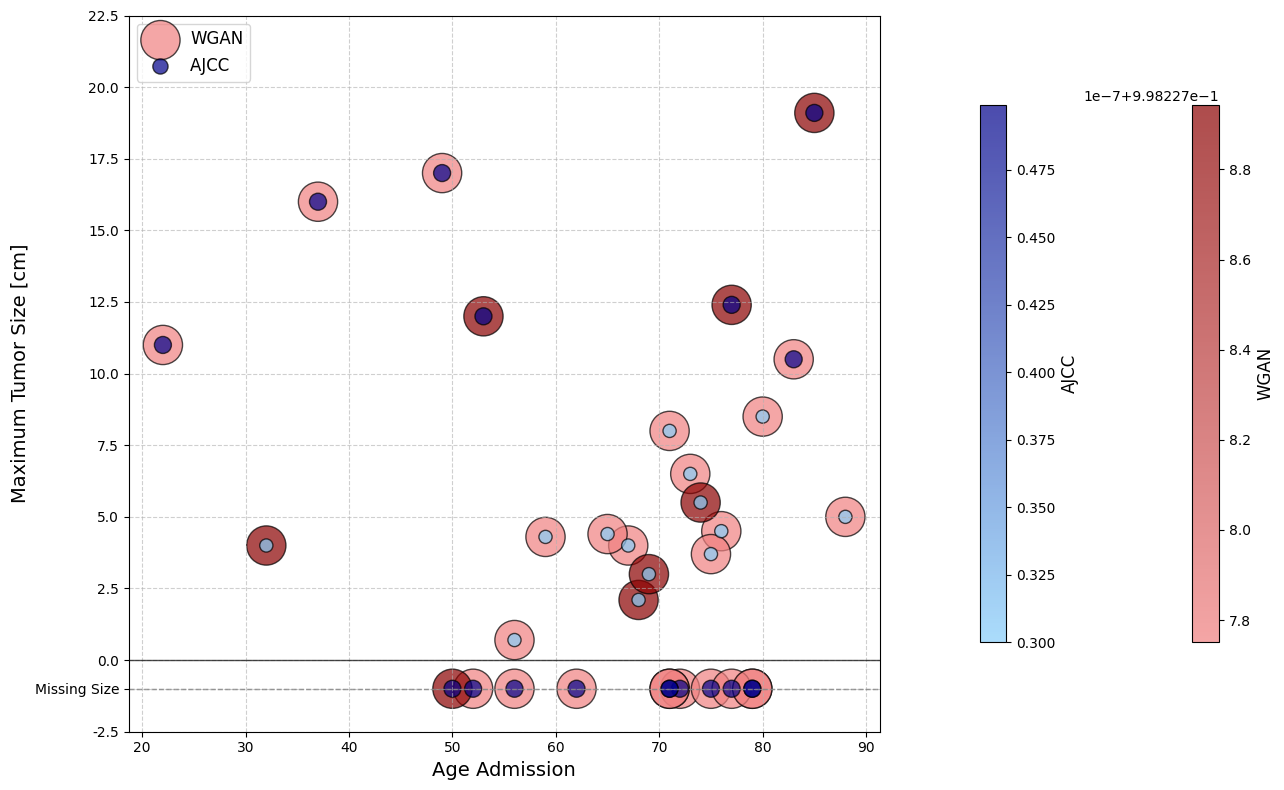

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Custom colormaps for Model and AJCC Risks
reds_cmap = LinearSegmentedColormap.from_list("custom_red", ["lightcoral", "darkred"])
blues_cmap = LinearSegmentedColormap.from_list("custom_blue", ["lightskyblue", "darkblue"])

# Normalize point sizes for better differentiation
model_sizes = model_correct['yes_disease'] * 800  # Scale model probabilities for size
ajcc_sizes = model_correct['staging_disease_prob'] * 300  # Scale AJCC probabilities for size

# Create a new column for visualizing missing size
model_correct['max_size_cm_filled'] = model_correct['max_size_cm'].fillna(-1)  # Use -1 to indicate missing size

# Plot setup
plt.figure(figsize=(14, 8))

# Plot for Model Risk
model_scatter = plt.scatter(
    x=model_correct['age_admission'], 
    y=model_correct['max_size_cm_filled'],  # Use the filled column
    c=model_correct['yes_disease'],  # Color represents your model's risk
    cmap=reds_cmap,
    s=model_sizes,  # Size scaled to model probabilities
    alpha=0.7, 
    edgecolors='k',
    label='WGAN'
)

# Plot for AJCC Risk
ajcc_scatter = plt.scatter(
    x=model_correct['age_admission'], 
    y=model_correct['max_size_cm_filled'],  # Use the filled column
    c=model_correct['staging_disease_prob'],  # Color represents AJCC's risk
    cmap=blues_cmap,  # Custom colormap for AJCC 
    s=ajcc_sizes,  # Size scaled to AJCC probabilities
    alpha=0.7, 
    edgecolors='k',
    label='AJCC '
)

# Add colorbars for each scatter plot
cbar_model = plt.colorbar(model_scatter, ax=plt.gca(), shrink=0.75)
cbar_model.set_label('WGAN', fontsize=12)

cbar_ajcc = plt.colorbar(ajcc_scatter, ax=plt.gca(), shrink=0.75, pad=0.1)
cbar_ajcc.set_label('AJCC', fontsize=12)
plt.axhline(y=-1, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Add a ticker line at size zero
plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.7)

# Highlight missing size cases without adding to legend
plt.axhline(y=-1, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Plot formatting
# plt.title("Age vs. Tumor Size with Model and AJCC Risk Probabilities (Including Missing Size)", fontsize=16)
plt.xlabel("Age Admission", fontsize=14)
plt.ylabel("Maximum Tumor Size [cm]", fontsize=14)
plt.yticks(list(plt.yticks()[0]) + [-1], labels=list(map(str, plt.yticks()[0])) + ["Missing Size"])
plt.grid(True, linestyle='--', alpha=0.6)

# Add legend for differentiation (excluding missing size line)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()

# Show plot
plt.show()



In [ ]:
df_validation['cgan_prob'] = pred_probs_median_cgan[:, 1]
df_validation['wgan_prob'] = pred_probs_median_wgan[:, 1]

# Brier Score
brier_model = brier_score_loss(df_validation['real_labels'], df_validation['yes_disease'])
brier_staging = brier_score_loss(df_validation['real_labels'], df_validation['staging_disease_prob'])
brier_cgan = brier_score_loss(df_validation['real_labels'], df_validation['cgan_prob'])
brier_wgan = brier_score_loss(df_validation['real_labels'], df_validation['wgan_prob'])

# Log Loss
log_loss_model = log_loss(df_validation['real_labels'], df_validation['yes_disease'])
log_loss_staging = log_loss(df_validation['real_labels'], df_validation['staging_disease_prob'])
log_loss_cgan = log_loss(df_validation['real_labels'], df_validation['cgan_prob'])
log_loss_wgan = log_loss(df_validation['real_labels'], df_validation['wgan_prob'])

# AUC-ROC Score
auc_roc_model = roc_auc_score(df_validation['real_labels'], df_validation['yes_disease'])
auc_roc_staging = roc_auc_score(df_validation['real_labels'], df_validation['staging_disease_prob'])
auc_roc_cgan = roc_auc_score(df_validation['real_labels'], df_validation['cgan_prob'])
auc_roc_wgan = roc_auc_score(df_validation['real_labels'], df_validation['wgan_prob'])

# Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
model_predictions = (df_validation['yes_disease'] >= 0.5).astype(int)
staging_predictions = (df_validation['staging_disease_prob'] >= 0.5).astype(int)
cgan_predictions = (df_validation['cgan_prob'] >= 0.5).astype(int)
wgan_predictions = (df_validation['wgan_prob'] >= 0.5).astype(int)

# Precision, Recall, F1 Score
precision_model = precision_score(df_validation['real_labels'], model_predictions)
recall_model = recall_score(df_validation['real_labels'], model_predictions)
f1_model = f1_score(df_validation['real_labels'], model_predictions)

precision_staging = precision_score(df_validation['real_labels'], staging_predictions)
recall_staging = recall_score(df_validation['real_labels'], staging_predictions)
f1_staging = f1_score(df_validation['real_labels'], staging_predictions)

precision_cgan = precision_score(df_validation['real_labels'], cgan_predictions)
recall_cgan = recall_score(df_validation['real_labels'], cgan_predictions)
f1_cgan = f1_score(df_validation['real_labels'], cgan_predictions)

precision_wgan = precision_score(df_validation['real_labels'], wgan_predictions)
recall_wgan = recall_score(df_validation['real_labels'], wgan_predictions)
f1_wgan = f1_score(df_validation['real_labels'], wgan_predictions)

# Compiling results into a DataFrame
metrics_df = pd.DataFrame({
    'Model': ['DNN', 'AJCC', 'CGAN', 'WGAN'],
    'Brier Score': [brier_model, brier_staging, brier_cgan, brier_wgan],
    'Log Loss': [log_loss_model, log_loss_staging, log_loss_cgan, log_loss_wgan],
    'AUC-ROC': [auc_roc_model, auc_roc_staging, auc_roc_cgan, auc_roc_wgan],
    'Precision': [precision_model, precision_staging, precision_cgan, precision_wgan],
    'Recall': [recall_model, recall_staging, recall_cgan, recall_wgan],
    'F1 Score': [f1_model, f1_staging, f1_cgan, f1_wgan]
})

# Display the DataFrame
print(metrics_df.round(2))

  Model  Brier Score  Log Loss  AUC-ROC  Precision  Recall  F1 Score
0   DNN         0.37      2.35     0.64       0.58    0.67      0.62
1  AJCC         0.23      0.66     0.68       0.67    0.07      0.13
2  CGAN         0.38      2.09     0.68       0.57    0.69      0.62
3  WGAN         0.36      2.19     0.71       0.59    0.67      0.63
